# Library Sections Performance Analysis

In this notebook, we analyze library sections to identify which parts of the collection achieve the strongest borrowing activity despite having a smaller number of titles.

The goal is not only to count how many books belong to each section, but also to compare that number with the total number of times books from that section have been borrowed.

This helps us detect sections that may be especially efficient or popular, even if they do not contain a large catalog.


## Why this analysis matters

A section with many titles does not automatically perform better than a smaller one.

To understand section performance more clearly, we will compare:

- the number of titles in each section
- the total number of borrowings in each section

After that, we will calculate a ratio that shows how much borrowing activity each section generates per title.

This gives us a simple way to spot sections that are highly active relative to their size.


## Step 1 - Import libraries

In [4]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append("..")
from source.books_data_prep import prepare_data

## Step 2 - Load the dataset

We begin by loading the dataset that contains book information.

In [5]:
df = pd.read_csv("../data/books.csv")
df.head()

,catalog_position,title,author,year_published,genre,section,total_copies,times_borrowed,last_borrowed_date,rating,ratings_count,price,language,page_count,isbn,subjects,dimensions,thumbnail
0,A1-B1-0001,Enormous Room,E. E. Cummings,1949,Drama,Fiction,5,3.0,6_Jan_25,4.14 out of 5 stars,2 ratings,$14.66,en,249.0,NaN,"Fiction, biographical, American fiction (ficti...",4.98 x 0.6 x 7.97 inches,http://books.google.com/books/content?id=mOGcE...
1,A1-B1-0002,Plutarchi Vitae parallelae,Plutarch,1478,Biography & Autobiography,History,4,1.0,19_Mar_24,No rating available,No reviews,$9.99,en,241.0,NaN,"Politics and government, Greek authors, Civili...",5.74 x 1.12 x 8.08 inches,NaN
2,A1-B1-0003,The water-babies,Charles Kingsley,1863,Fantasy,Children,6,6.0,5_Jun_24,4.21 out of 5 stars,6 ratings,$13.89,en,228.0,NaN,"Chimney sweeps, Open Library Staff Picks, Fict...",7.7 x 0.7 x 5.1 inches,NaN
3,A1-B1-0004,Kipps,H. G. Wells,1900,Comedy,Fiction,4,5.0,6_Nov_24,4.44 out of 5 stars,4 ratings,$370,eng,386.0,NaN,"Fiction, Young men, Working class, Orphans, Br...",5.08 x 0.98 x 7.8 inches,NaN
4,A1-B1-0005,Man and Superman,George Bernard Shaw,1903,Drama,Fiction,5,2.0,16_Jan_25,4.46 out of 5 stars,2 ratings,$10.99,en,220.0,NaN,"English Dramatists, English drama, Translation...",5.08 x 1.22 x 7.8 inches,NaN


## Step 3 - Prepare the data

Before starting the analysis, we apply a custom preparation function.

This step helps ensure that the dataset is cleaned and standardized before grouping and aggregating the values.


In [6]:
df = prepare_data(df)
df.info()

<class 'pandas.DataFrame'>
Index: 2087 entries, 0 to 2103
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   catalog_position    2087 non-null   str           
 1   title               2087 non-null   str           
 2   author              2087 non-null   str           
 3   year_published      2083 non-null   Int16         
 4   genre               2087 non-null   category      
 5   section             2029 non-null   category      
 6   total_copies        2074 non-null   Int16         
 7   times_borrowed      2081 non-null   Int16         
 8   last_borrowed_date  2074 non-null   datetime64[us]
 9   rating              1764 non-null   float64       
 10  ratings_count       1759 non-null   float64       
 11  price               1888 non-null   float64       
 12  language            2084 non-null   category      
 13  page_count          2082 non-null   Int16         
 14  subjects

## Step 4 - Group the data by section

Now we group the dataset by the `section` column.

For each section, we calculate:

- how many titles belong to that section
- the total number of times books from that section have been borrowed

This gives us the basic summary needed for the comparison.

In [7]:
inventory_gap = df.groupby("section").agg({
    "title": "count",
    "times_borrowed": "sum"
})

inventory_gap

,title,times_borrowed
section,,
Children,236,6233
Fiction,1146,48185
History,39,522
Humanities,233,896
Non-Fiction,215,21595
Rare Books,12,0
Reference,52,718
Science,28,992
Young Adult,68,13632


## Step 5 - Improve column clarity

The aggregated result is useful, but the column names can be made clearer.

We will rename them so the table is easier to interpret.

In [8]:
inventory_gap = inventory_gap.rename(columns={
    "title": "title_count",
    "times_borrowed": "total_borrowings"
})

inventory_gap


,title_count,total_borrowings
section,,
Children,236,6233
Fiction,1146,48185
History,39,522
Humanities,233,896
Non-Fiction,215,21595
Rare Books,12,0
Reference,52,718
Science,28,992
Young Adult,68,13632


## Step 6 - Calculate the borrowing-to-title ratio

To better understand section efficiency, we calculate a new metric:

**borrowing-to-title ratio**

This ratio shows how many total borrowings are generated, on average, by one title in a section.

A higher value suggests that a section performs strongly relative to its size.


In [9]:
inventory_gap["titles_to_borrow_ratio"] = (
    inventory_gap["total_borrowings"] / inventory_gap["title_count"]
)

inventory_gap


,title_count,total_borrowings,titles_to_borrow_ratio
section,,,
Children,236,6233,26.411017
Fiction,1146,48185,42.046248
History,39,522,13.384615
Humanities,233,896,3.845494
Non-Fiction,215,21595,100.44186
Rare Books,12,0,0.0
Reference,52,718,13.807692
Science,28,992,35.428571
Young Adult,68,13632,200.470588


## Step 7 - Sort the results

To identify the strongest-performing sections, we sort the table by the borrowing-to-title ratio in descending order.

This places the most efficient sections at the top.


In [10]:
inventory_gap_sorted = inventory_gap.sort_values(
    by="titles_to_borrow_ratio",
    ascending=False
).reset_index()


## Step 8 - Visualizing the analysis results

Now that we have calculated the `titles_to_borrow_ratio`, we can visualize the results using a bar chart.

The chart will show how each library section performs based on the number of borrowings compared to the number of available titles. This makes it easier to identify sections where books are borrowed more frequently in relation to the size of the collection.

In other words, the visualization helps us see which sections may have strong demand but a relatively limited number of titles.


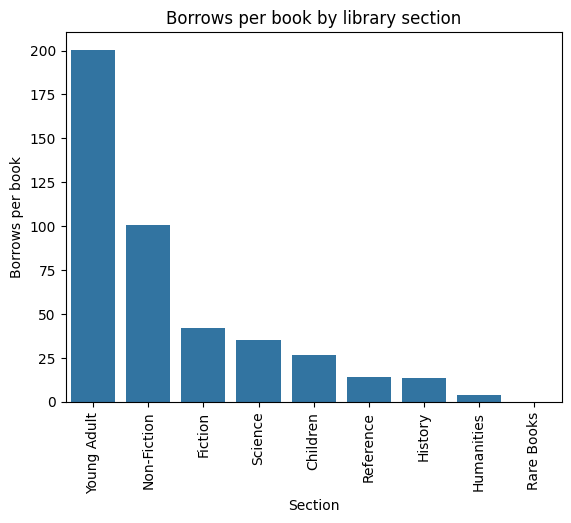

In [11]:
sns.barplot(
    data=inventory_gap_sorted,
    x="section",
    y="titles_to_borrow_ratio",
    order=inventory_gap_sorted['section']
)

plt.title("Borrows per book by library section")
plt.xlabel("Section")
plt.ylabel("Borrows per book")
plt.xticks(rotation=90)

plt.show()

## Interpretation

The results show clear differences in how efficiently each section uses its catalog.

**Young Adult** stands out as the strongest performer, with a ratio of over **200 borrowings per title**.  
Despite having only 68 titles, it generates extremely high borrowing activity, indicating strong and consistent reader demand.

**Non-Fiction** also performs very well, with a ratio above **100**, showing that this section combines both solid catalog size and high usage.

In contrast, **Fiction**, although by far the largest section (1146 titles), has a significantly lower ratio (~42).  
This suggests that borrowing activity is spread across a large number of titles, and that many books may be underutilized.

**Science** shows moderate efficiency (~35), while **Children** (~26) performs slightly lower than expected given its size.

At the lower end, **Reference**, **History**, and especially **Humanities** have very low ratios, indicating limited borrowing relative to their catalog size.

Finally, **Rare Books** has no borrowing activity at all, which is expected due to the nature of the collection.

---

## Conclusion

This analysis reveals that the most valuable sections are not necessarily the largest ones, but those that achieve the highest borrowing activity per title.

Sections like **Young Adult** and **Non-Fiction** demonstrate strong demand and efficient use of a relatively small catalog.  
These sections may benefit from expansion, as additional titles are likely to be actively used.

On the other hand, large sections such as **Fiction** could benefit from deeper analysis, such as identifying underperforming titles or refining the catalog.

Low-performing sections like **Humanities** and **Reference** may require strategic decisions — whether through promotion, reorganization, or reevaluation of acquisition priorities.

Overall, this type of ratio-based analysis provides a clearer picture of real usage patterns and supports more targeted, data-driven decisions in library management.